# **Objective 1: Identify Key Factors Influencing Happiness Score**
Goal: Use statistical techniques and correlation analysis to find out which variables (GDP, Freedom, Health, etc.) most influence the Happiness Score.


Data Overview:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 24 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Country                    4000 non-null   object 
 1   Year                       4000 non-null   int64  
 2   Happiness_Score            4000 non-null   float64
 3   GDP_per_Capita             4000 non-null   float64
 4   Social_Support             4000 non-null   float64
 5   Healthy_Life_Expectancy    4000 non-null   float64
 6   Freedom                    4000 non-null   float64
 7   Generosity                 4000 non-null   float64
 8   Corruption_Perception      4000 non-null   float64
 9   Unemployment_Rate          4000 non-null   float64
 10  Education_Index            4000 non-null   float64
 11  Population                 4000 non-null   int64  
 12  Urbanization_Rate          4000 non-null   float64
 13  Life_Satisfaction          4000 n

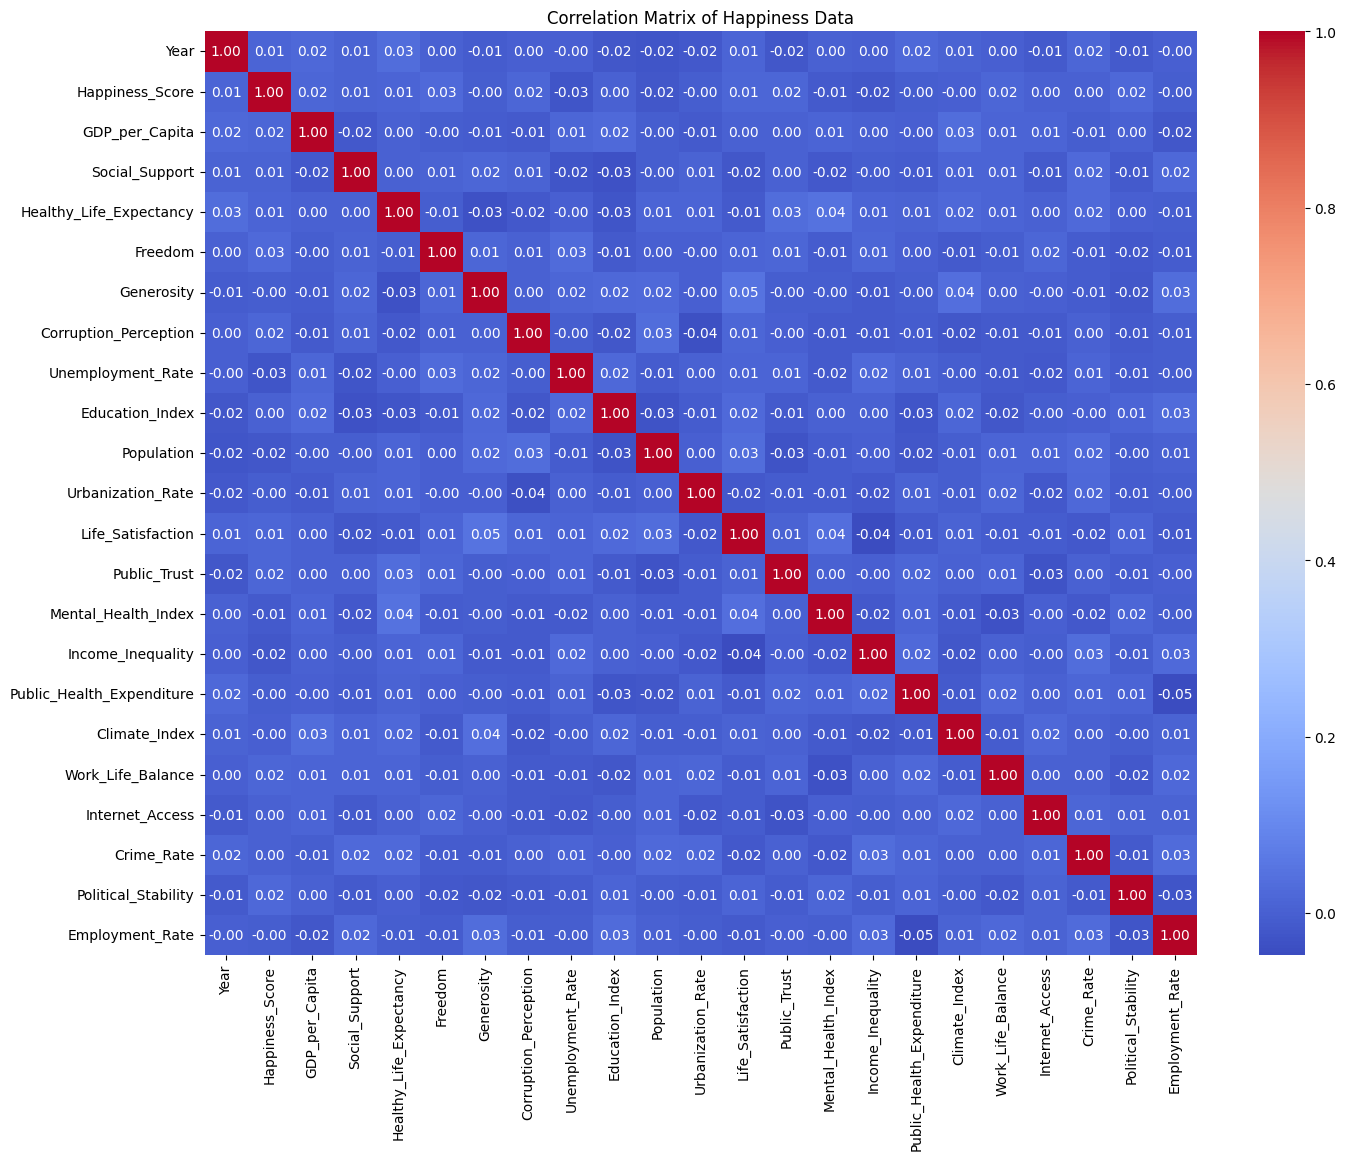


Top Factors Positively Correlated with Happiness Score:
Freedom                0.025273
Political_Stability    0.018827
GDP_per_Capita         0.016324
Work_Life_Balance      0.016085
Public_Trust           0.015138
Name: Happiness_Score, dtype: float64

Top Factors Negatively Correlated with Happiness Score:
Urbanization_Rate     -0.004861
Mental_Health_Index   -0.013628
Population            -0.021352
Income_Inequality     -0.022347
Unemployment_Rate     -0.025534
Name: Happiness_Score, dtype: float64

VIF Data:
                  Feature        VIF
0                   const  68.362580
1       Unemployment_Rate   1.002090
2                 Freedom   1.001715
3       Income_Inequality   1.002940
4              Population   1.003156
5     Political_Stability   1.001028
6          GDP_per_Capita   1.000564
7       Work_Life_Balance   1.001148
8            Public_Trust   1.001482
9   Corruption_Perception   1.001937
10      Life_Satisfaction   1.003718

Linear Regression Coefficients:
Fr

In [9]:
#Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm

#Load the dataset
df = pd.read_csv("/content/happpy.csv")

#Display basic information
print("Data Overview:")
print(df.info())
print("\nSummary Statistics:")
print(df.describe())

#Correlation matrix
corr_matrix = df.corr(numeric_only=True)
plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix of Happiness Data")
plt.show()

#Identify top correlated variables with Happiness_Score
correlations = corr_matrix["Happiness_Score"].drop("Happiness_Score").sort_values(ascending=False)
print("\nTop Factors Positively Correlated with Happiness Score:")
print(correlations.head())

print("\nTop Factors Negatively Correlated with Happiness Score:")
print(correlations.tail())

#VIF (Variance Inflation Factor) for multicollinearity check

top_features = correlations.abs().sort_values(ascending=False).head(10).index.tolist()
X = df[top_features].dropna()
X = sm.add_constant(X)
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print("\nVIF Data:")
print(vif_data)

#Build a simple linear regression model
# Using top 5 features to predict Happiness_Score
selected_features = correlations.head(5).index.tolist()
X = df[selected_features]
y = df["Happiness_Score"]
model = LinearRegression()
model.fit(X, y)
print("\nLinear Regression Coefficients:")
for feat, coef in zip(selected_features, model.coef_):
    print(f"{feat}: {coef:.4f}")
print(f"Intercept: {model.intercept_:.4f}")


# **Objective 2: Compare Happiness Scores Across Regions and Years**
Goal: Perform exploratory analysis to understand trends over time and across countries/regions.

Unique countries: 10
Years covered: 2005 - 2024


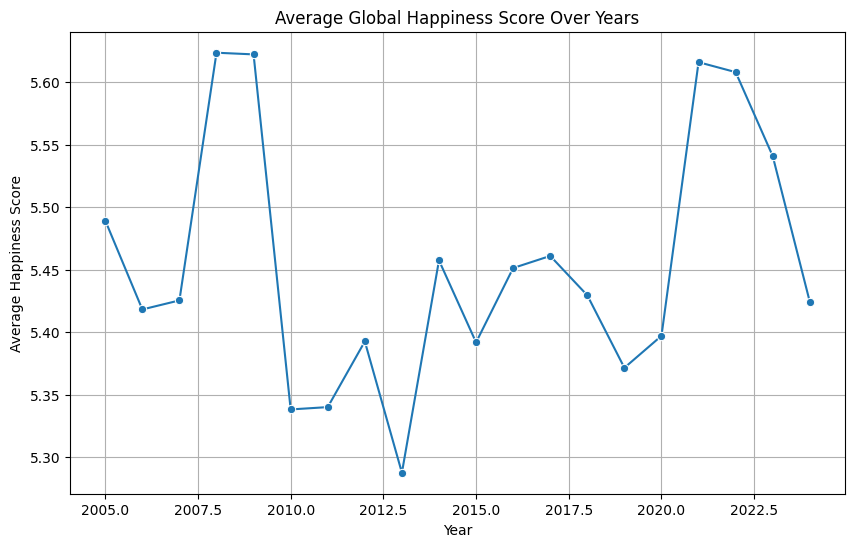

<ipython-input-10-53db8b40ca7b>:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_country.values, y=avg_country.index, palette="viridis")


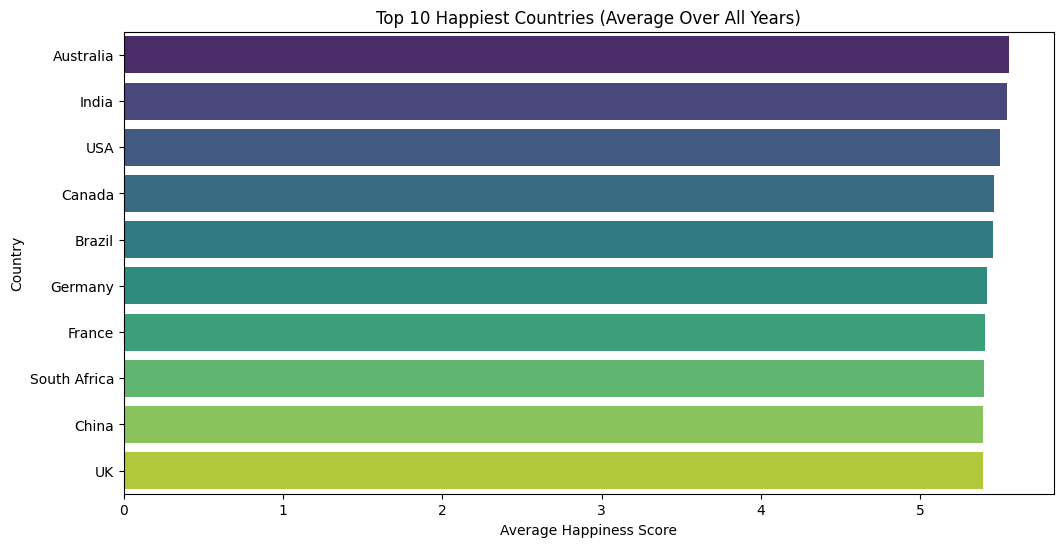

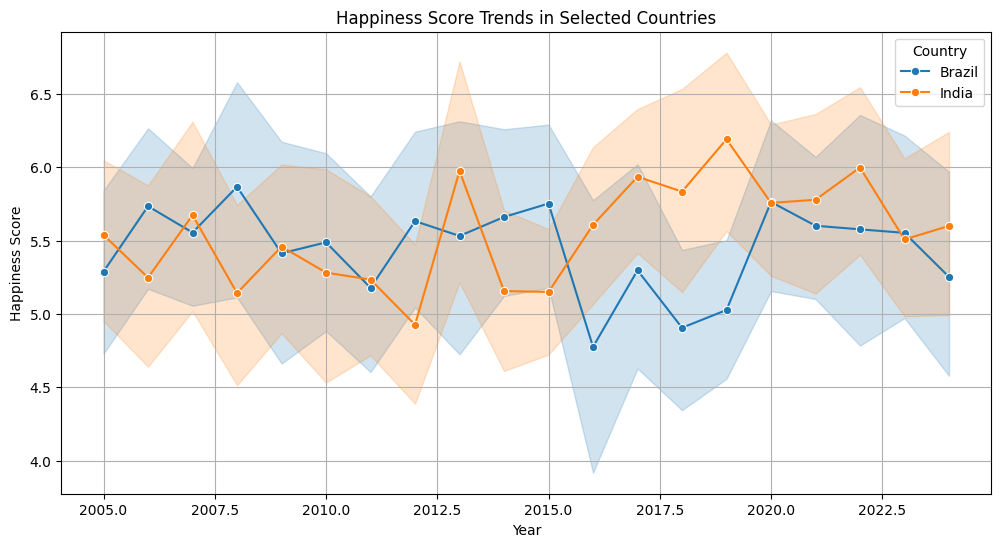

In [10]:
#Compare Happiness Scores Across Regions and Years

#Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#Load dataset
df = pd.read_csv("happpy.csv")

#Check unique countries and year ranges
print("Unique countries:", df["Country"].nunique())
print("Years covered:", df["Year"].min(), "-", df["Year"].max())

#Average happiness score by year
avg_year = df.groupby("Year")["Happiness_Score"].mean().reset_index()

# Plot trend over time
plt.figure(figsize=(10, 6))
sns.lineplot(data=avg_year, x="Year", y="Happiness_Score", marker="o")
plt.title("Average Global Happiness Score Over Years")
plt.xlabel("Year")
plt.ylabel("Average Happiness Score")
plt.grid(True)
plt.show()

#Top 10 happiest countries (average over all years)
avg_country = df.groupby("Country")["Happiness_Score"].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=avg_country.values, y=avg_country.index, palette="viridis")
plt.title("Top 10 Happiest Countries (Average Over All Years)")
plt.xlabel("Average Happiness Score")
plt.ylabel("Country")
plt.show()

#Compare Happiness in Selected Countries Over Time
selected_countries = ["Norway", "Sweden", "India", "United States", "Brazil"]
df_selected = df[df["Country"].isin(selected_countries)]

plt.figure(figsize=(12, 6))
sns.lineplot(data=df_selected, x="Year", y="Happiness_Score", hue="Country", marker="o")
plt.title("Happiness Score Trends in Selected Countries")
plt.xlabel("Year")
plt.ylabel("Happiness Score")
plt.legend(title="Country")
plt.grid(True)
plt.show()


# **Objective 3: Examine the Impact of Mental Health, Employment & Income Inequality on Happiness**
Goal: Analyze how mental well-being, employment rates, and inequality affect happiness levels.

Summary Statistics:
       Happiness_Score  Mental_Health_Index  Employment_Rate
count      4000.000000          4000.000000      4000.000000
mean          5.455005            69.976853        74.021450
std           1.427370            17.128536        13.906888
min           3.000000            40.000000        50.000000
25%           4.237500            55.580000        61.867500
50%           5.430000            69.650000        74.475000
75%           6.662500            84.582500        85.912500
max           8.000000           100.000000        98.000000
Shapiro-Wilk Test for Happiness_Score: W=0.9574, p-value=0.0000
Shapiro-Wilk Test for Mental_Health_Index: W=0.9579, p-value=0.0000
Shapiro-Wilk Test for Employment_Rate: W=0.9543, p-value=0.0000


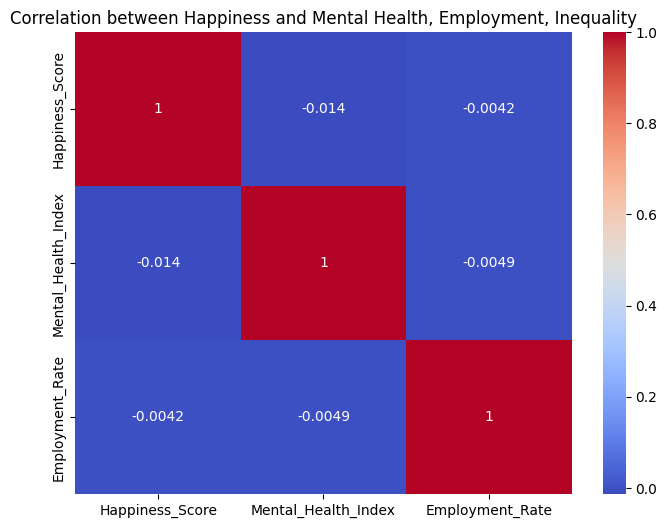

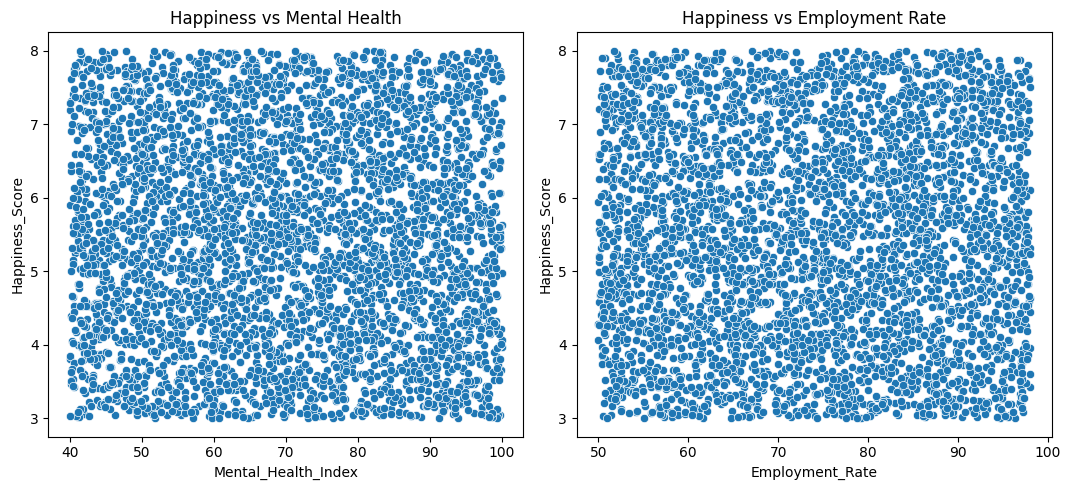

Pearson Correlation between Happiness_Score and Mental_Health_Index: r=-0.0136, p-value=0.3889
Pearson Correlation between Happiness_Score and Employment_Rate: r=-0.0042, p-value=0.7901


In [20]:
#Import required libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import shapiro, pearsonr

# Step 2: Load dataset
df = pd.read_csv("happpy.csv")

# Select relevant columns and check missing data
cols_of_interest = ["Happiness_Score", "Mental_Health_Index", "Employment_Rate"]
df_subset = df[cols_of_interest].dropna()

#Summary statistics
print("Summary Statistics:")
print(df_subset.describe())

#Distribution checks using Shapiro-Wilk Test
for col in cols_of_interest:
    stat, p = shapiro(df_subset[col])
    print(f"Shapiro-Wilk Test for {col}: W={stat:.4f}, p-value={p:.4f}")

#Correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df_subset.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation between Happiness and Mental Health, Employment, Inequality")
plt.show()

#Scatter plots
plt.figure(figsize=(16, 5))

# Mental Health
plt.subplot(1, 3, 1)
sns.scatterplot(data=df_subset, x="Mental_Health_Index", y="Happiness_Score")
plt.title("Happiness vs Mental Health")

# Employment Rate
plt.subplot(1, 3, 2)
sns.scatterplot(data=df_subset, x="Employment_Rate", y="Happiness_Score")
plt.title("Happiness vs Employment Rate")

plt.tight_layout()
plt.show()

#Pearson correlation test
for col in cols_of_interest[1:]:
    corr, p_value = pearsonr(df_subset[col], df_subset["Happiness_Score"])
    print(f"Pearson Correlation between Happiness_Score and {col}: r={corr:.4f}, p-value={p_value:.4f}")


# **Objective 4: Investigate the Relationship Between Public Trust and Government Metrics**
Goal: Explore how Public Trust correlates with Government Spending, Political Stability, and Corruption Perception.

Summary Statistics:
       Public_Trust  Public_Health_Expenditure  Political_Stability  \
count   4000.000000                4000.000000          4000.000000   
mean       0.502812                   6.009270             0.494105   
std        0.289186                   2.291172             0.293191   
min        0.000000                   2.010000             0.000000   
25%        0.260000                   4.040000             0.230000   
50%        0.500000                   6.070000             0.490000   
75%        0.760000                   8.010000             0.760000   
max        1.000000                  10.000000             1.000000   

       Corruption_Perception  Happiness_Score  
count            4000.000000      4000.000000  
mean                0.498920         5.455005  
std                 0.288866         1.427370  
min                 0.000000         3.000000  
25%                 0.240000         4.237500  
50%                 0.500000         5.430000  
75% 

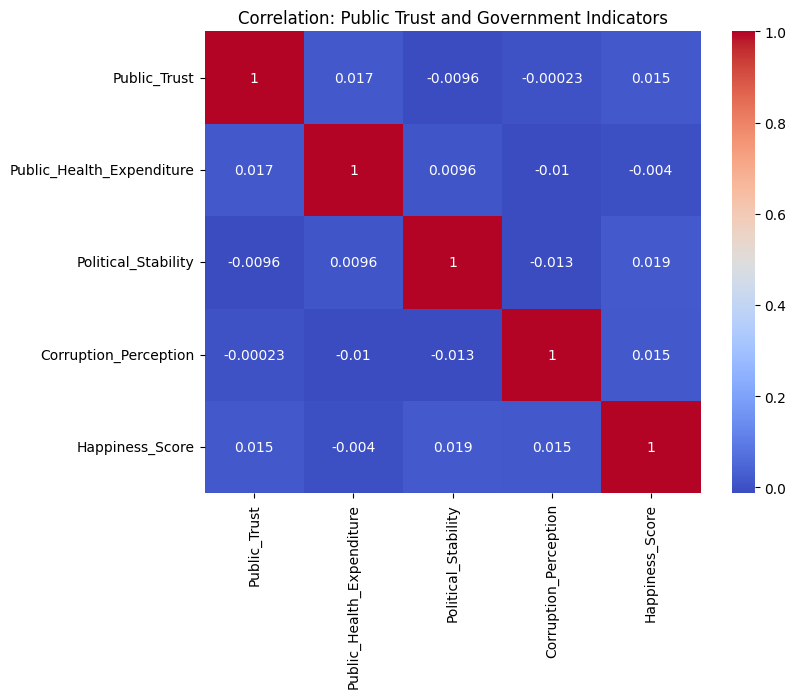

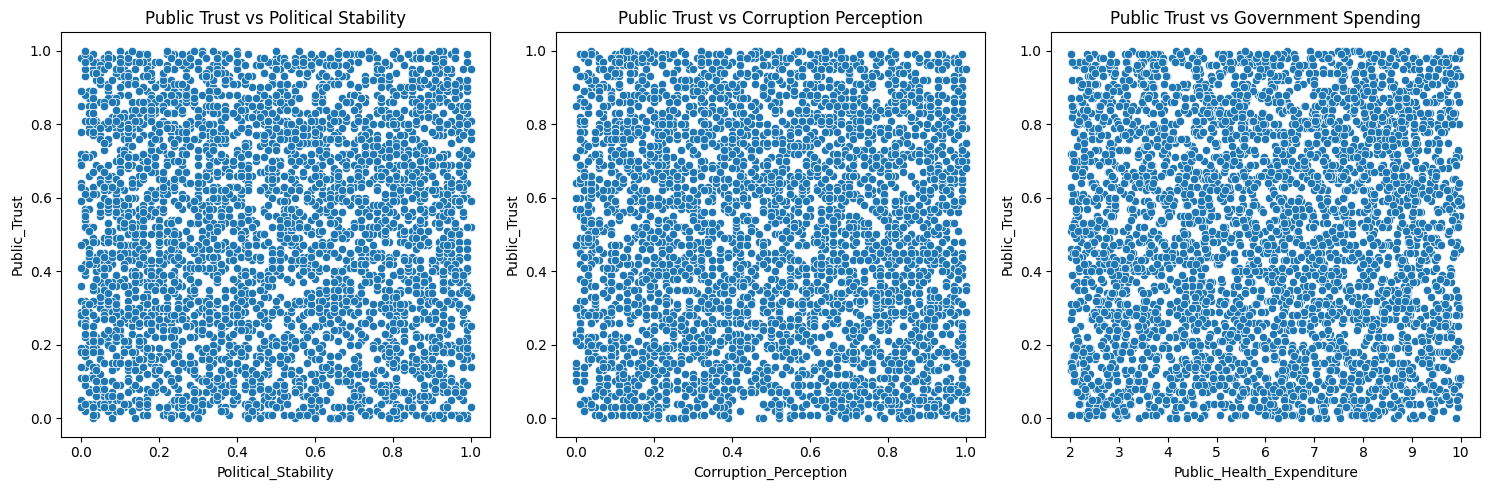

Correlation between Public_Trust and Political_Stability: r = -0.0096, p-value = 0.5450
Correlation between Public_Trust and Corruption_Perception: r = -0.0002, p-value = 0.9885
Correlation between Public_Trust and Public_Health_Expenditure: r = 0.0165, p-value = 0.2956


In [25]:
#Select relevant columns
cols = [
    "Public_Trust",
    "Public_Health_Expenditure",
    "Political_Stability",
    "Corruption_Perception",
    "Happiness_Score"
]
df_gov = df[cols].dropna()

#Summary statistics
print("Summary Statistics:")
print(df_gov.describe())

#Correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df_gov.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation: Public Trust and Government Indicators")
plt.show()

#Scatter plots for visual insights
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.scatterplot(data=df_gov, x="Political_Stability", y="Public_Trust")
plt.title("Public Trust vs Political Stability")

plt.subplot(1, 3, 2)
sns.scatterplot(data=df_gov, x="Corruption_Perception", y="Public_Trust")
plt.title("Public Trust vs Corruption Perception")

plt.subplot(1, 3, 3)
sns.scatterplot(data=df_gov, x="Public_Health_Expenditure", y="Public_Trust")
plt.title("Public Trust vs Government Spending")

plt.tight_layout()
plt.show()

#Pearson correlation analysis
metrics = ["Political_Stability", "Corruption_Perception", "Public_Health_Expenditure"]
for metric in metrics:
    corr, p_val = pearsonr(df_gov["Public_Trust"], df_gov[metric])
    print(f"Correlation between Public_Trust and {metric}: r = {corr:.4f}, p-value = {p_val:.4f}")


# **Objective 5: Build a Basic Predictive Model for Happiness Score**
Goal: Use linear regression to model Happiness Score from top predictors found in Objective 1

Model Evaluation:
R-squared: -0.0013
MAE: 1.2284
MSE: 2.0212
RMSE: 1.4217

Feature Coefficients:
GDP_per_Capita: 0.0000
Social_Support: 0.0108
Freedom: 0.0817
Healthy_Life_Expectancy: 0.0029
Public_Trust: 0.0868


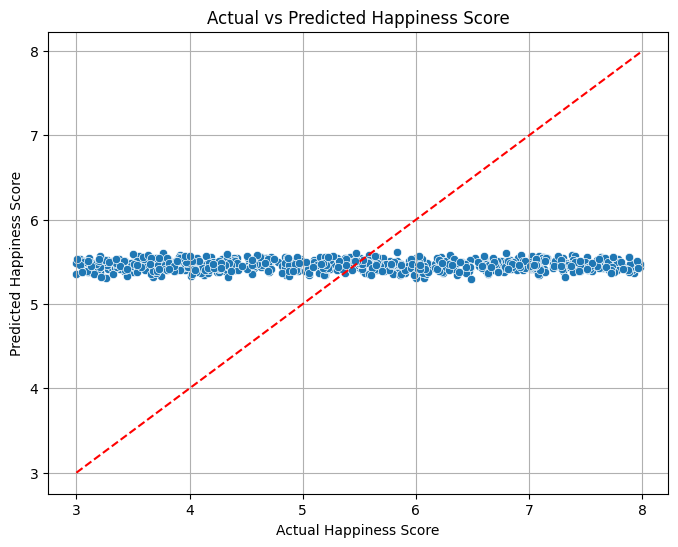

In [24]:
#Load the dataset
df = pd.read_csv("happpy.csv")

#Select features and target
features = [
    "GDP_per_Capita",
    "Social_Support",
    "Freedom",
    "Healthy_Life_Expectancy",
    "Public_Trust"
]
target = "Happiness_Score"

#Handle missing values
df_model = df[features + [target]].dropna()

#Define input (X) and output (y)
X = df_model[features]
y = df_model[target]

#Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#Train a Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

#Make predictions
y_pred = model.predict(X_test)

#Evaluate model performance
print("Model Evaluation:")
print(f"R-squared: {r2_score(y_test, y_pred):.4f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred):.4f}")
print(f"MSE: {mean_squared_error(y_test, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")

#Show feature importance (coefficients)
print("\nFeature Coefficients:")
for feat, coef in zip(features, model.coef_):
    print(f"{feat}: {coef:.4f}")

#Plot predicted vs actual values
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
plt.xlabel("Actual Happiness Score")
plt.ylabel("Predicted Happiness Score")
plt.title("Actual vs Predicted Happiness Score")
plt.grid(True)
plt.show()
